In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [9]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


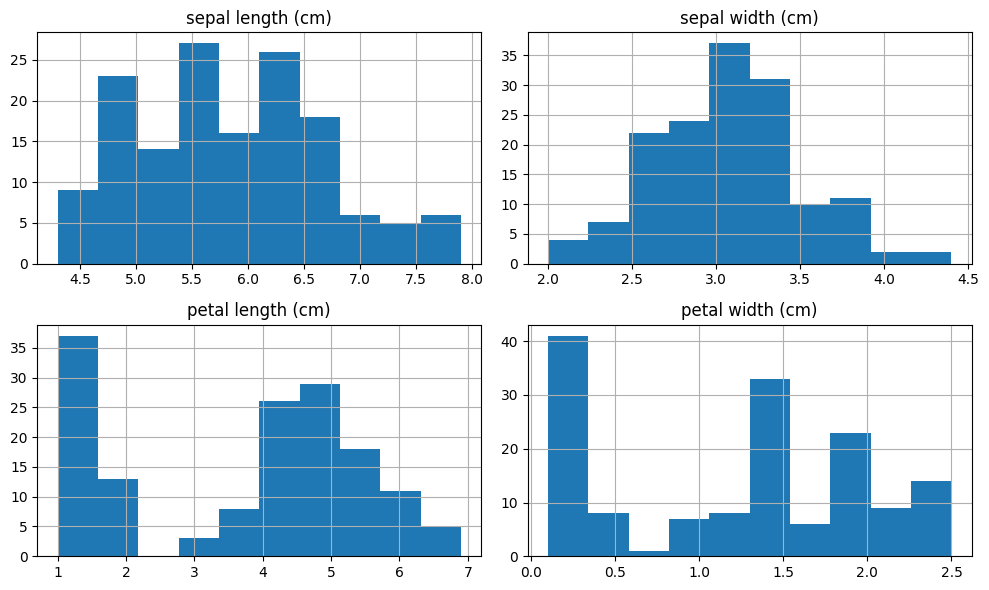

In [10]:
feature_cols = iris.feature_names

df[feature_cols].hist(figsize=(10,6))
plt.tight_layout()
plt.show()

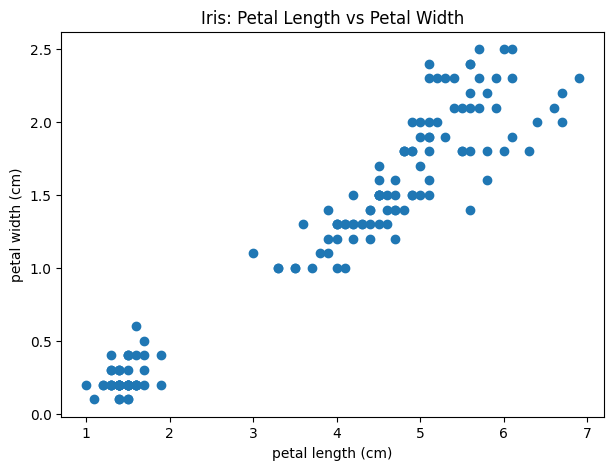

In [11]:
plt.figure(figsize=(7,5))
plt.scatter(df["petal length (cm)"], df["petal width (cm)"])
plt.xlabel("petal length (cm)")
plt.ylabel("petal width (cm)")
plt.title("Iris: Petal Length vs Petal Width")
plt.show()

In [12]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X = df[feature_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
k_labels = kmeans.fit_predict(X_scaled)

df["kmeans_cluster"] = k_labels
df["kmeans_cluster"].value_counts()

,count
kmeans_cluster,
0,53
1,50
2,47


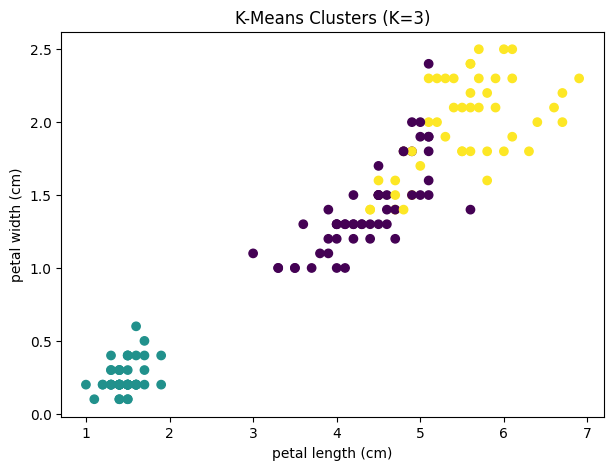

In [13]:
plt.figure(figsize=(7,5))
plt.scatter(df["petal length (cm)"], df["petal width (cm)"], c=df["kmeans_cluster"])
plt.xlabel("petal length (cm)")
plt.ylabel("petal width (cm)")
plt.title("K-Means Clusters (K=3)")
plt.show()

In [15]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.6, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

df["dbscan_cluster"] = db_labels
df["dbscan_cluster"].value_counts()

,count
dbscan_cluster,
1,78
0,46
-1,26


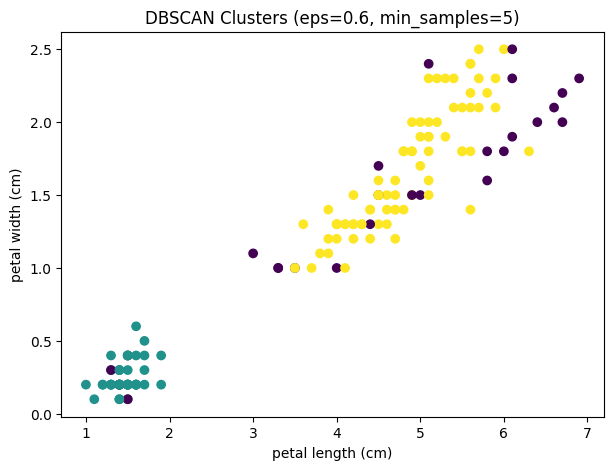

In [16]:
plt.figure(figsize=(7,5))
plt.scatter(df["petal length (cm)"], df["petal width (cm)"], c=df["dbscan_cluster"])
plt.xlabel("petal length (cm)")
plt.ylabel("petal width (cm)")
plt.title("DBSCAN Clusters (eps=0.6, min_samples=5)")
plt.show()

**Clustering Analysis Reflection**

Observed Patterns

From the visualizations, the petal length and petal width features show the clearest seperation between groups. The scatter plot of petal length versus petal width reveals three visible clusters. One cluster is tightly grouped with smaller petal measurements, while the other clusters have larger petal measurements and show more variation.. Sepal measurements appear more evenly distibuted and do not seperate the groups as cleanly.


**Effect of Changing K in K-Means**


The value of K in K-Means determines how many clusters the algorithm attempts to reate. If the value of K is too small, different natural groups in the data may be merged into the same cluster. If the value is too large, natural groups may be split into multiple smaller clusters. In this dataset, using K=3 works well because the Iris dataset contains three natural species groups.


**Comparison Between K-Means and DBSCAN**


K-Means assigns every data point to a cluster and assumes clusters are roughly spherical in shape. DBSCAN works differently because it groups points based on density and can mark some points as noise if they do not belong to a dense region. In this dataset, DBSCAN identidied two main clusters and labeled some points as noise. This shows that DBSCAN can be more sensitive to the density paramenters and may treat border points differently than K-means.